Quantum Potential Capture

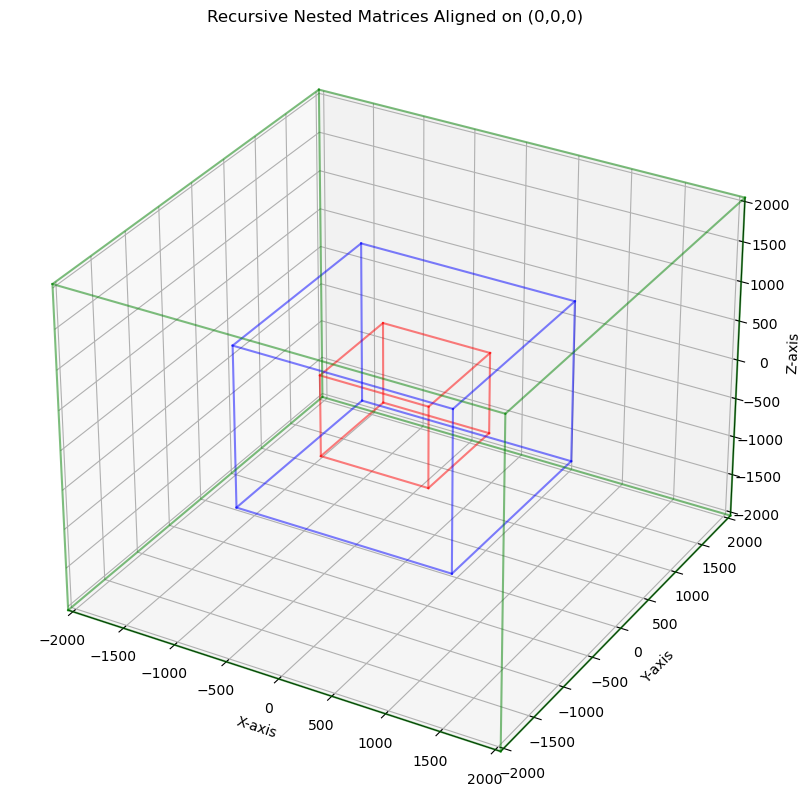

In [21]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

def create_harmonic_nested_matrices(frame_size, recursion_depth):
    """
    Create nested matrices with recursive alignment based on the Nexus 2 Framework.

    Args:
        frame_size (int): The base size of the smallest cube (D - sample window).
        recursion_depth (int): The number of recursive levels.

    Returns:
        list: A list of dictionaries containing vertices and edges for each nested matrix.
    """
    def create_cube_vertices(center, side_length):
        """
        Generate vertices for a cube centered at `center` with `side_length`.
        """
        half = side_length / 2
        cx, cy, cz = center
        return np.array([
            [cx - half, cy - half, cz - half],  # Bottom-left-front
            [cx + half, cy - half, cz - half],  # Bottom-right-front
            [cx + half, cy + half, cz - half],  # Top-right-front
            [cx - half, cy + half, cz - half],  # Top-left-front
            [cx - half, cy - half, cz + half],  # Bottom-left-back
            [cx + half, cy - half, cz + half],  # Bottom-right-back
            [cx + half, cy + half, cz + half],  # Top-right-back
            [cx - half, cy + half, cz + half],  # Top-left-back
        ])

    def create_cube_edges():
        """
        Define the edges for a cube.
        """
        return [
            (0, 1), (1, 2), (2, 3), (3, 0),  # Bottom face
            (4, 5), (5, 6), (6, 7), (7, 4),  # Top face
            (0, 4), (1, 5), (2, 6), (3, 7)   # Vertical edges
        ]

    matrices = []
    center = (0, 0, 0)

    for i in range(recursion_depth):
        side_length = frame_size * (2 ** i)
        vertices = create_cube_vertices(center, side_length)
        edges = create_cube_edges()
        matrices.append({
            'vertices': vertices,
            'edges': edges,
            'side_length': side_length
        })

    return matrices

def visualize_nested_matrices(matrices):
    """
    Visualize nested matrices in 3D.

    Args:
        matrices (list): A list of dictionaries containing vertices and edges.
    """
    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot(111, projection='3d')

    colors = ['red', 'blue', 'green']
    alpha = 0.5

    for i, matrix in enumerate(matrices):
        vertices = matrix['vertices']
        edges = matrix['edges']
        color = colors[i % len(colors)]

        for edge in edges:
            start, end = edge
            ax.plot(
                [vertices[start][0], vertices[end][0]],
                [vertices[start][1], vertices[end][1]],
                [vertices[start][2], vertices[end][2]],
                color=color,
                alpha=alpha
            )

    max_dim = matrices[-1]['side_length'] / 2
    ax.set_xlim([-max_dim, max_dim])
    ax.set_ylim([-max_dim, max_dim])
    ax.set_zlim([-max_dim, max_dim])
    ax.set_xlabel('X-axis')
    ax.set_ylabel('Y-axis')
    ax.set_zlabel('Z-axis')
    ax.set_title('Recursive Nested Matrices Aligned on (0,0,0)')
    plt.show()

def main():
    frame_size = 1024  # Base size of the smallest cube (D)
    recursion_depth = 3  # Number of recursive levels (D -> O -> G)

    matrices = create_harmonic_nested_matrices(frame_size, recursion_depth)
    visualize_nested_matrices(matrices)

if __name__ == "__main__":
    main()


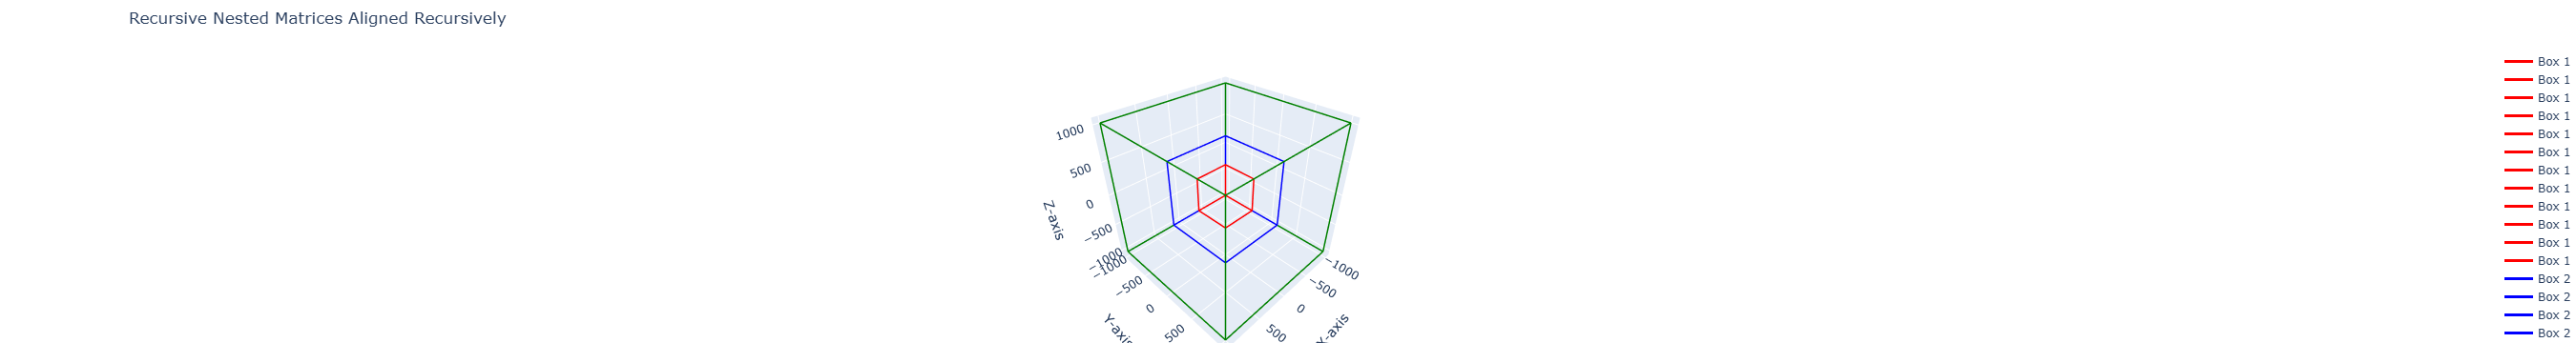

In [55]:
import numpy as np
import plotly.graph_objects as go

def create_single_matrix(center, frame_size):
    """
    Create a single matrix (box) with a given center and frame size.

    Args:
        center (tuple): The center of the matrix (x, y, z).
        frame_size (int): The size of the matrix.

    Returns:
        dict: Dictionary containing vertices and edges of the matrix.
    """
    half = frame_size / 2
    cx, cy, cz = center

    vertices = np.array([
        [cx - half, cy - half, cz - half],  # Bottom-left-front
        [cx + half, cy - half, cz - half],  # Bottom-right-front
        [cx + half, cy + half, cz - half],  # Top-right-front
        [cx - half, cy + half, cz - half],  # Top-left-front
        [cx - half, cy - half, cz + half],  # Bottom-left-back
        [cx + half, cy - half, cz + half],  # Bottom-right-back
        [cx + half, cy + half, cz + half],  # Top-right-back
        [cx - half, cy + half, cz + half],  # Top-left-back
    ])

    edges = [
        (0, 1), (1, 2), (2, 3), (3, 0),  # Bottom face
        (4, 5), (5, 6), (6, 7), (7, 4),  # Top face
        (0, 4), (1, 5), (2, 6), (3, 7)   # Vertical edges
    ]

    return {'vertices': vertices, 'edges': edges, 'frame_size': frame_size}

def recursive_matrices(frame_size, recursion_depth):
    """
    Generate recursive matrices starting at (0, 0, 0) and using the calculated center of the previous box.

    Args:
        frame_size (int): The base size of the smallest matrix.
        recursion_depth (int): The number of recursive levels.

    Returns:
        list: A list of matrices with their vertices and edges.
    """
    matrices = []
    center = (0, 0, 0)

    for i in range(recursion_depth):
        current_size = frame_size * (2 ** i)
        matrix = create_single_matrix(center, current_size)
        matrices.append(matrix)
        # Calculate the new center as the center of the previous matrix
        center = tuple(np.mean(matrix['vertices'], axis=0))

    return matrices

def visualize_recursive_matrices_plotly(matrices):
    """
    Visualize recursive matrices in 3D using Plotly.

    Args:
        matrices (list): A list of dictionaries containing vertices and edges.
    """
    fig = go.Figure()

    colors = ['red', 'blue', 'green', 'purple', 'orange']

    for i, matrix in enumerate(matrices):
        vertices = matrix['vertices']
        edges = matrix['edges']
        color = colors[i % len(colors)]

        # Add edges as 3D lines
        for edge in edges:
            start, end = edge
            fig.add_trace(go.Scatter3d(
                x=[vertices[start][0], vertices[end][0]],
                y=[vertices[start][1], vertices[end][1]],
                z=[vertices[start][2], vertices[end][2]],
                mode='lines',
                line=dict(color=color, width=3),
                name=f'Box {i + 1}'
            ))

    # Set layout
    fig.update_layout(
        title="Recursive Nested Matrices Aligned Recursively",
        scene=dict(
            xaxis_title="X-axis",
            yaxis_title="Y-axis",
            zaxis_title="Z-axis",
            aspectmode='cube'
        ),
        margin=dict(l=0, r=0, t=50, b=0)
    )

    fig.show()

def main():
    frame_size = 512  # Base size of the smallest matrix
    recursion_depth = 3  # Number of recursive levels

    matrices = recursive_matrices(frame_size, recursion_depth)
    visualize_recursive_matrices_plotly(matrices)

if __name__ == "__main__":
    main()
